### 1.b Import data and explore

#### 1.b.i - Describing the data

The data contains 9568 data points depicting the enery output of a power plant and the ambient conditions at the power plant, over the course of six years.

Power is generated by a combination of steam and gas turbines.

- AT - Temperature
- AP - Ambient Pressure
- RH - Relative Humidity
- V - Exhaust Vaccum
- PE - Power output

Data source and citation: Tfekci, P. & Kaya, H. (2014). Combined Cycle Power Plant [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5002N.

In [10]:
import pandas
import matplotlib.pyplot as plot
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [11]:
data = pandas.read_excel("../data/Folds5x2_pp.xlsx")

data

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90
...,...,...,...,...,...
9563,16.65,49.69,1014.01,91.00,460.03
9564,13.19,39.18,1023.67,66.78,469.62
9565,31.32,74.33,1012.92,36.48,429.57
9566,24.48,69.45,1013.86,62.39,435.74


#### 1.b.ii - Scatter plots

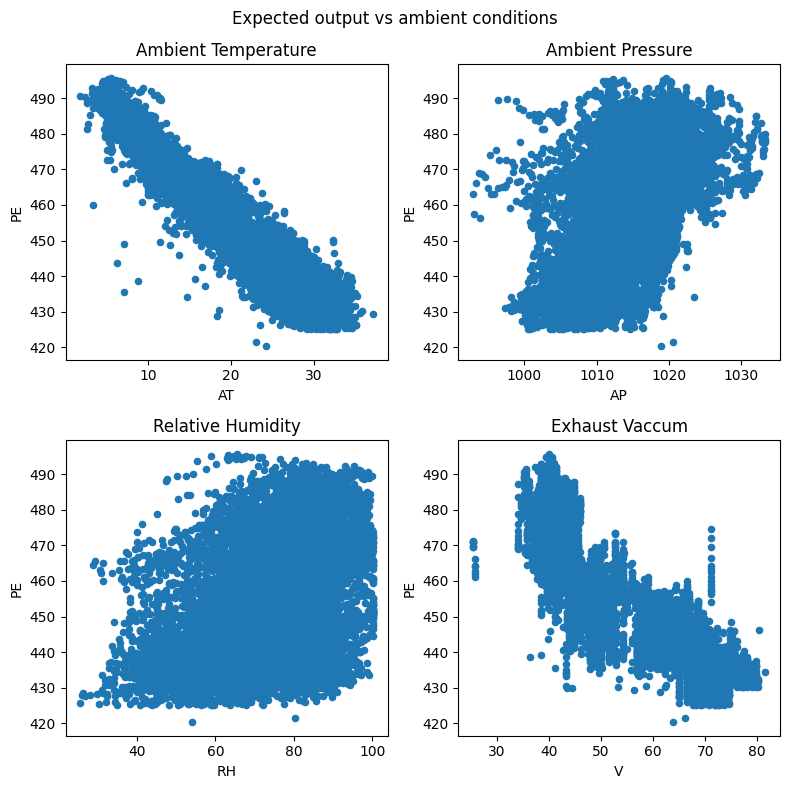

In [12]:
overall_figure, axes = plot.subplots(2,2, figsize=(8,8))

overall_figure.suptitle("Expected output vs ambient conditions")

axes[0][0].set_title("Ambient Temperature")
data.plot(kind="scatter", x="AT", y="PE", ax=axes[0][0])

axes[0][1].set_title("Ambient Pressure")
data.plot(kind="scatter", x="AP", y="PE", ax=axes[0][1])

axes[1][0].set_title("Relative Humidity")
data.plot(kind="scatter", x="RH", y="PE", ax=axes[1][0])

axes[1][1].set_title("Exhaust Vaccum")
data.plot(kind="scatter", x="V", y="PE", ax=axes[1][1])

overall_figure.tight_layout()

Visually the following trends may be observed:
- There seems to be a decrease in the Power output with increase in ambient temperature (AT) and Exhaust Vaccum (V).
- The power output seems to increase with increase in ambient pressure (AP)
- The upper limit on power output seems to increase with increase in relative humidity



#### 1.b.iii - Find stats from the data

In [13]:
pandas.concat([
        data.mean(),
        data.median(),
        data.max() - data.min(),
        data.quantile(0.25),
        data.quantile(0.75)
    ],
    axis=1,
    keys=["Mean", "Median", "Range", "1st Quartile", "3rd Quartile"])

,Mean,Median,Range,1st Quartile,3rd Quartile
AT,19.651231,20.345,35.30,13.5100,25.72
V,54.305804,52.080,56.20,41.7400,66.54
AP,1013.259078,1012.940,40.41,1009.1000,1017.26
RH,73.308978,74.975,74.60,63.3275,84.83
PE,454.365009,451.550,75.50,439.7500,468.43


### 1.c Linear Regression with individual predictors

The following code fits a linear regression model for each predictor, and records useful results

In [14]:
results = []

for col in data.columns:
    if col == 'PE':
        break

    model = sm.OLS(data['PE'], sm.add_constant(data[col])).fit()
    results.append({
        'Predictor': col,
        'P Value': model.pvalues[col],
        'R squared': round(model.rsquared,2),
        'Model': model
    })

pandas.DataFrame([{key: x[key] for key in ['Predictor', 'P Value', 'R squared']} for x in results])

,Predictor,P Value,R squared
0,AT,0.0,0.90
1,V,0.0,0.76
2,AP,0.0,0.27
3,RH,0.0,0.15


With a P value very close to zero, we can say that there is a statistically significant correlation between each predictor and the response, but we may deduce that the predictors Ambient Temperature (AT) and Exhaust Vaccum (V) are better predictors, with their larger $R^{2}$ metric

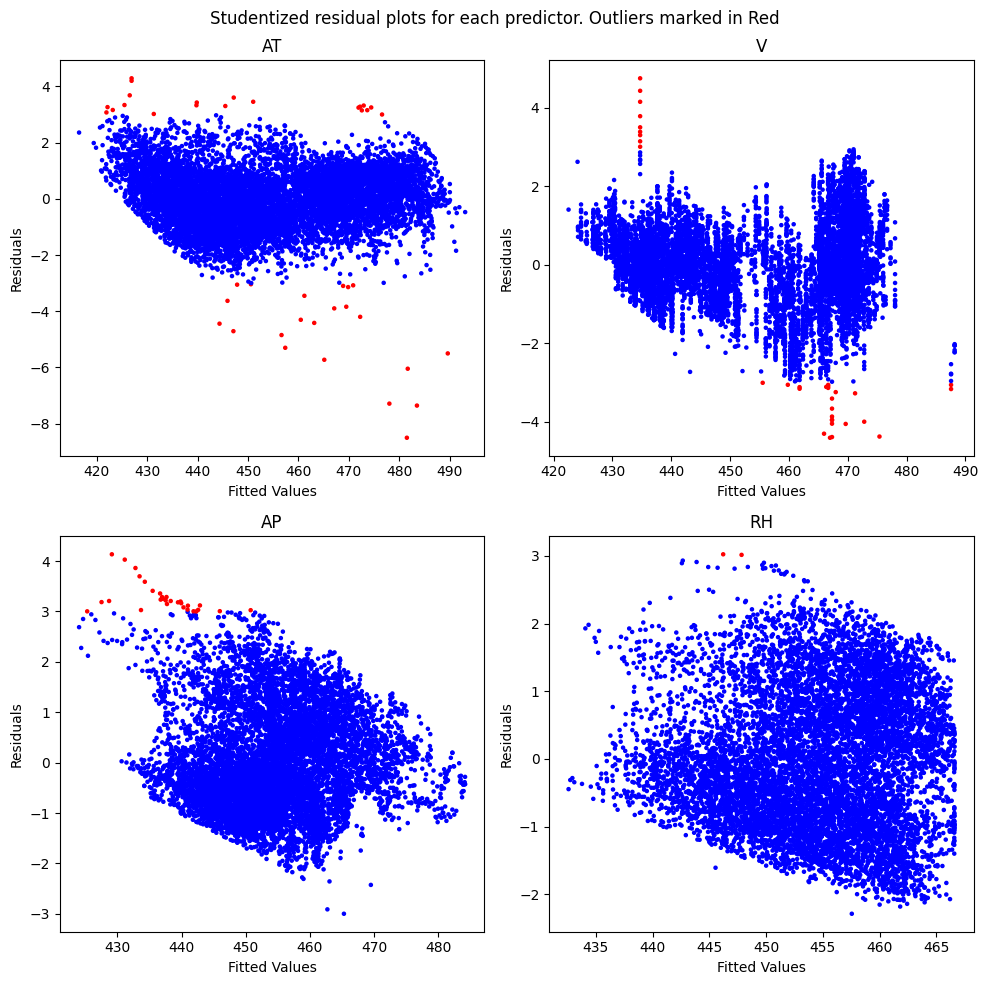

In [15]:
overall_figure, axes = plot.subplots(2,2,figsize=(10,10))

overall_figure.suptitle("Studentized residual plots for each predictor. Outliers marked in Red")

for i in range(len(results)):

    st_residuals = results[i]["Model"].get_influence().resid_studentized_external

    colors = ['r' if abs(x) > 3 else 'b' for x in st_residuals]

    axes[i//2][i%2].scatter(results[i]['Model'].fittedvalues,st_residuals,s=5,c=colors)
    axes[i//2][i%2].set_title(f"{results[i]['Predictor']}")
    axes[i//2][i%2].set_xlabel("Fitted Values")
    axes[i//2][i%2].set_ylabel("Residuals")

overall_figure.tight_layout()
overall_figure.show()

The above scatter plots show the studentized residual plots for each predictor. The plots for Ambient Pressure (AP) and Relative Humidity (RH) show a noticable linear relationship to the fitted values, further validating the possibility that they show a weaker linear correlation to the response as compared to Ambient Temperature (AT) and Exhaust Volume (V) whose plots show a random distribution of residuals about the x axis.

The points on this plot with absolute value of studentized residuals greater than 3 may be considered **outliers** and are marked in red.

### 1.d Linear Regression with multiple predictors

In [16]:
model = sm.OLS(data['PE'], sm.add_constant(data.drop(columns='PE'))).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 14 Feb 2025   Prob (F-statistic):               0.00
Time:                        08:57:30   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

Given the above summary of stats calculated by fitting a linear regression model for the given data, we can see that all variables have a P value lower than 0.05. This indicates that there is a statistically significant correlation between every one of the predictors and the response. AP however seems to have the lowest correlation, whereas AT has the highest.

### 1.e Comparing the two

Multiple linear regression seems to find a better fit overall, with a slightly larger $R^{2}$ value. The plots below show the relationship between the estimated coefficients for each of the predictors during simple and multiple linear regression.

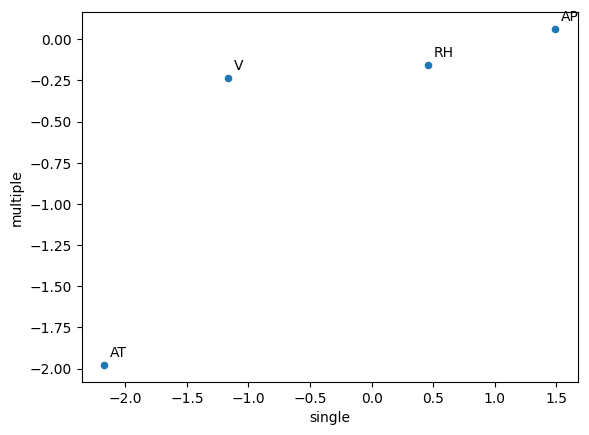

In [17]:
coefficients = [{
        'predictor': x['Predictor'],
        'single': x['Model'].params[x['Predictor']],
        'multiple': model.params[x['Predictor']]
    } for x in results]

pandas.DataFrame(coefficients).plot(kind='scatter',x='single',y='multiple')
for c in coefficients:
    plot.annotate(c['predictor'], (c['single']+0.05,c['multiple']+0.05))

### 1.f Checking for non-linear relationships

The following code calculates the $R^{2}$ value for each predictor when trying to fit an equation of the form:

$Y = \beta_{0} + \beta_{1}X + \beta_{2}X^{2} + \beta_{3}X^3$

The code also presents the coefficient and P-value for each power of the predictor

In [18]:
results = {
    ('General', 'Name'): [],
    ('General', 'R Squared'): [],
    ('Coefficients', 'Linear'): [],
    ('Coefficients', 'Squared'): [],
    ('Coefficients', 'Cubed'): [],
    ('P Values', 'Linear'): [],
    ('P Values', 'Squared'): [],
    ('P Values', 'Cubed'): [],
}

for col in data.columns:

    if col == 'PE':
        break

    X = pandas.DataFrame()
    X['linear'], X['squared'], X['cubed'] = data[col], data[col]**2, data[col]**3
    model = sm.OLS(data['PE'], sm.add_constant(X)).fit()
    results[('General', 'Name')].append(col)
    results[('Coefficients', 'Linear')].append(model.params['linear'])
    results[('Coefficients', 'Squared')].append(model.params['squared'])
    results[('Coefficients', 'Cubed')].append(model.params['cubed'])
    results[('P Values', 'Linear')].append(model.pvalues['linear'])
    results[('P Values', 'Squared')].append(model.pvalues['squared'])
    results[('P Values', 'Cubed')].append(model.pvalues['cubed'])
    results[('General', 'R Squared')].append(model.rsquared)

pandas.DataFrame(results)

General           Coefficients                          P Values  \
     Name R Squared       Linear   Squared     Cubed        Linear   
0      AT  0.911883    -0.610346 -0.125138  0.002675  7.898147e-07   
1       V  0.775022    -2.144377 -0.002712  0.000134  2.526589e-05   
2      AP  0.274863    25.255593 -0.049952  0.000025  4.502735e-17   
3      RH  0.153743    -1.729211  0.032145 -0.000152  3.772510e-04   

                                
        Squared          Cubed  
0  8.833045e-73  3.652185e-110  
1  7.684969e-01   1.373489e-02  
2  3.666705e-17   8.264146e-18  
3  9.395430e-06   1.440279e-05

AT seems to improve it's goodness of fit slightly with P values indicating that there is some non linear correlation involved.

For other predictors, the P values indicate that there is some statistically significant non linear correlation, but there is no significant change in goodness of fit as compared to linear correlation.

### 1.g Checking for pairwise interactions

In [19]:
formula = "PE ~ AT:V + AT:AP + AT:RH + V:AP + V:RH + AP:RH"
model = smf.ols(formula, sm.add_constant(data)).fit()

print(f"R squared value = {model.rsquared}")
print("P - Values")
model.pvalues

R squared value = 0.9334624102449646
P - Values


Intercept     0.000000e+00
AT:V          1.079482e-50
AT:AP        1.455360e-226
AT:RH         5.942091e-04
V:AP          7.571283e-10
V:RH          3.452069e-11
AP:RH         6.956411e-06
dtype: float64

We can see that the R squared value is very close to one, and most pairs show a p value that is very close to zero. We may deduce that all pairs are statistically significant, and their inclusion could improve the fit of the model.

Among the pairs, we see that AT|RH and AP|RH have higher p values, indicating relatively lower levels of correlation.

### 1.h Combining all predictors

In [20]:
X_train, X_test, y_train, y_test = train_test_split(data.drop(columns='PE'), data['PE'], test_size=0.3)

# Create simple linear regression model

simple_model = sm.OLS(y_train, sm.add_constant(X_train)).fit()
simple_predictions = simple_model.predict(sm.add_constant(X_test))

print(f"R2 score for simple linear regression is: {r2_score(y_test, simple_predictions)}")

# Prepare data with higher order terms

X_train['AT2'] = X_train['AT']**2
X_train['AP2'] = X_train['AP']**2
X_train['V2'] = X_train['V']**2
X_train['RH2'] = X_train['RH']**2
X_train['AT:AP'] = X_train['AT']*X_train['AP']
X_train['AT:V'] = X_train['AT']*X_train['V']
X_train['AT:RH'] = X_train['AT']*X_train['RH']
X_train['AP:V'] = X_train['AP']*X_train['V']
X_train['AP:RH'] = X_train['AP']*X_train['RH']
X_train['V:RH'] = X_train['V']*X_train['RH']

X_test['AT2'] = X_test['AT']**2
X_test['AP2'] = X_test['AP']**2
X_test['V2'] = X_test['V']**2
X_test['RH2'] = X_test['RH']**2
X_test['AT:AP'] = X_test['AT']*X_test['AP']
X_test['AT:V'] = X_test['AT']*X_test['V']
X_test['AT:RH'] = X_test['AT']*X_test['RH']
X_test['AP:V'] = X_test['AP']*X_test['V']
X_test['AP:RH'] = X_test['AP']*X_test['RH']
X_test['V:RH'] = X_test['V']*X_test['RH']

complex_model = sm.OLS(y_train, sm.add_constant(X_train)).fit()
complex_predictions = complex_model.predict(sm.add_constant(X_test))

print(f"R2 score for linear regression with higher order terms is: {r2_score(y_test, complex_predictions)}")

R2 score for simple linear regression is: 0.9315098593762728
R2 score for linear regression with higher order terms is: 0.9391676817306079


We are able to slightly improve the fit by adding higher order terms.

### Compare with KNN

In [21]:
def KNN(X,y,k_range,test_size,should_normalize):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size)
    if should_normalize:
        scaler = MinMaxScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    min_error = None

    train_errors = []
    test_errors = []

    for k in k_range:
        predictor = KNeighborsRegressor(n_neighbors=k).fit(X_train, y_train)
        predictions = predictor.predict(X_test)
        mse = mean_squared_error(y_test, predictions)
        r2 = r2_score(y_test, predictions)

        train_predictions = predictor.predict(X_train)
        train_mse = mean_squared_error(y_train, train_predictions)

        if min_error == None:
            min_error = (k, mse, r2)
        elif min_error[1] > mse:
            min_error = (k, mse, r2)

        train_errors.append(train_mse)
        test_errors.append(mse)

    return (min_error, test_errors, train_errors)

raw_results = KNN(data.drop(columns='PE'),
          data['PE'],
          k_range=[x for x in range(1,101)],
          test_size=0.3,
          should_normalize=False)

normalized_results = KNN(data.drop(columns='PE'),
          data['PE'],
          k_range=[x for x in range(1,101)],
          test_size=0.3,
          should_normalize=True)

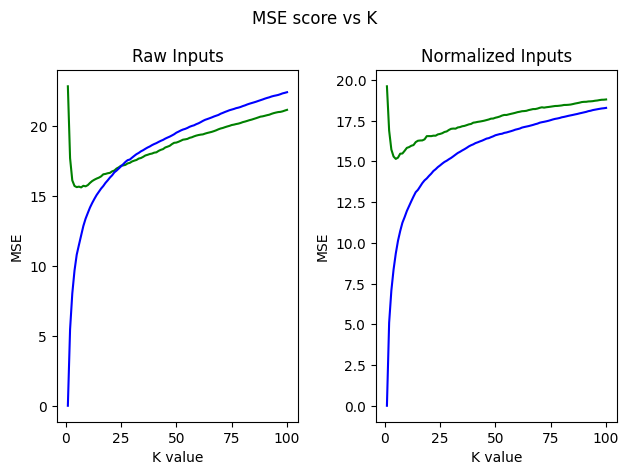

In [22]:
raw_test_vs_k = [x for x in raw_results[1]]
raw_train_vs_k = [x for x in raw_results[2]]
normalized_test_vs_k = [x for x in normalized_results[1]]
normalized_train_vs_k = [x for x in normalized_results[2]]
k_range = [x for x in range(1,101)]

overall_figure, axes = plot.subplots(1,2)

overall_figure.suptitle("MSE score vs K")

axes[0].plot(k_range, raw_test_vs_k, c='g')
axes[0].plot(k_range, raw_train_vs_k, c='b')
axes[0].set_title("Raw Inputs")
axes[0].set_xlabel("K value")
axes[0].set_ylabel("MSE")

axes[1].plot(k_range, normalized_test_vs_k, c='g')
axes[1].plot(k_range, normalized_train_vs_k, c='b')
axes[1].set_title("Normalized Inputs")
axes[1].set_xlabel("K value")
axes[1].set_ylabel("MSE")

overall_figure.tight_layout()
overall_figure.show()

In the above graph, the blue line represents the training error, and the red line represents the test error.

In [23]:
pandas.DataFrame([list(raw_results[0]), list(normalized_results[0])], index=["Raw", "Normalized"], columns=["Best K", "Mean squared error", "R2 score"])

,Best K,Mean squared error,R2 score
Raw,7,15.592708,0.946641
Normalized,5,15.159920,0.947567


We can see from the R2 score that KNN seems to perform slightly better than Linear regression when the inputs are normalized.

In this case, we have a large dataset of nearly 10,000 data points that are concentrated in a relatively small range, with low dimensionality, allowing for a large number of neighbours to be assessed in the locality of a point, likely improving the performance of KNN.

Linear Regression, while almost as performant, relies on the underlying correlation between predictors and response to be linear, which in this case may act as a limitation.

### Conceptual questions:

#### Question 2

For each of parts (a) through (d), indicate whether we would generally expect the performance of a flexible statistical learning method to be better or worse than an inflexible method. Justify your answer.

(a) The sample size n is extremely large, and the number of predictors p is small.

 - In this case, a flexible method would probably work better as it has the scope to make use of the large number of datapoints with dimensionality, whereas an inflexible method has fewer predictors to work with, and cannot make good use of the large number of data points.

(b) The number of predictors p is extremely large, and the number of observations n is small.

- In this case, an inflexible method would probably work better, as it is able to use underlying assumptions about the data to make up for lack of data points, and is able to make use of the large number of predictors. Both of these factors impede the performance of a flexible method.

(c) The relationship between the predictors and response is highly non-linear.

- In this case, we could expect a flexible method to perform better, as we are unable to make an accurate assumption about the underlying correlations between the predictors and the response. A flexible method might be able to better fit the data based on a large number of datapoints.

(d) The variance of the error terms, i.e. σ2 = Var(ϵ), is extremely high.

- In this case, an inflexible method may perform better as a more flexible method is at higher risk of being influced by noisy readings.

#### Question 3

(a) Compute the Euclidean distance between each observation and the test point, $X_1 = X_2 = X_3 = 0$

- Distances to points:

| Point | Distance |
| --- | --- |
| 1 | 3 |
| 2 | 2 |
| 3 | $\sqrt{10}$ |
| 4 | $\sqrt{5}$ |
| 5 | $\sqrt{2}$ |
| 6 | $\sqrt{3}$ |

(b) What is our prediction with $K = 1$? Why?

- Nearest neighbour is point 5, with class Green, hence prediction will be 'Green'

(c) What is our prediction with $K = 3$ ? Why?

- Nearest neighbours are points 5, 6, and 2, two of which are Red. The prediction is 'Red'

(d) If the Bayes decision boundary in this problem is highly non linear, then would we expect the *best* value for $K$ to be large or small? Why?

- We would expect the best value for $K$ to be small, as a highly non linear boundary implies that neighbours that are not very close to the point do not influence the point as much.